# Candidate Test 2022 Analysis Part 2

This exercise focuses on the candidate tests from two television networks: DR and TV2. Data from both tests have been given on a scale of five responses (-2, -1, 0, 1, 2). Consider normalizing the data or performing similar scaling transformations as needed.

---

There are 6 datasets included in this exercise:

- `alldata.xlsx`: Contains responses from both TV stations.
- `drdata.xlsx`: Contains responses from DR.
- `drq.xlsx`: Contains questions from DR.
- `tv2data.xlsx`: Contains responses from TV2.
- `tv2q.xlsx`: Contains questions from TV2.
- `electeddata.xlsx`: Contains responses from both TV stations for candidates who were elected to the parliament. Note that 9 members are missing; 7 of them didn't take any of the tests. Additionally, some notable figures like Mette F. and Lars Løkke did not participate in any of the tests.

---

It's entirely up to you how you approach this data, but at a *minimum*, your analysis should include:

- An analysis/description of which questions are most crucial concerning their placement on the axes.
- Average positions of parties concerning each question, preferably with accompanying plots of each (or selected) question.
- A clustering analysis where you attempt various cluster numbers, which would correspond to different parties. Discuss whether there is room for more clusters/parties or if a reduction is needed. Make sure you cover: **K-Means, Hierarchical clustering, and DBSCAN.**
- An overview of the political landscape of the elected candidates, highlighting which members agree or disagree the most and which parties or party members have significant disagreements.
- Feel free to explore further and remember that preprocessing, methodology, and evaluation metrics are not mentioned explicitly, but are implicitly assumed.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| D | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Æ | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Z | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| G | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)


Others have undertaken similar analyses. You can draw inspiration from the following (use Google tranlsate if your Danish is rusty):

- [Analysis of where individual candidates stand relative to each other and their parties](https://v2022.dumdata.dk/)
- [Candidate Test 2022 – A deep dive into the data](https://kwedel.github.io/kandidattest2022/)
- [The Political Landscape 2019](https://kwedel.github.io/kandidattest2019/)



## 1. Indlæs data og bibliotekter

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# --- Indlæs alle datasæt ---
alldata     = pd.read_excel('alldata.xlsx')      # 867 kandidater, alle spørgsmål
drdata      = pd.read_excel('drdata.xlsx')        # DR-besvarelser
tv2data     = pd.read_excel('tv2data.xlsx')       # TV2-besvarelser
drq         = pd.read_excel('drq.xlsx')           # DR-spørgsmål metadata
tv2q        = pd.read_excel('tv2q.xlsx')          # TV2-spørgsmål metadata
electeddata = pd.read_excel('electeddata.xlsx')   # Kun valgte kandidater

print(f"alldata:     {alldata.shape}  (alle kandidater)")
print(f"electeddata: {electeddata.shape}  (kun valgte)")
print(f"DR spørgsmål:  {drq.shape[0]}")
print(f"TV2 spørgsmål: {tv2q.shape[0]}")

# --- Identificer spørgsmålskolonner (numeriske) og metadata ---
meta_cols = ['navn', 'parti', 'storkreds', 'alder']
question_cols = [c for c in alldata.columns if c not in meta_cols]
print(f"\nAntal spørgsmålskolonner i alldata: {len(question_cols)}")
print(f"Partier i datasættet: {sorted(alldata['parti'].unique())}")

alldata:     (867, 53)  (alle kandidater)
electeddata: (169, 53)  (kun valgte)
DR spørgsmål:  25
TV2 spørgsmål: 74

Antal spørgsmålskolonner i alldata: 49
Partier i datasættet: ['Alternativet', 'Danmarksdemokraterne', 'Dansk Folkeparti', 'Det Konservative Folkeparti', 'Enhedslisten', 'Frie Grønne, Danmarks Nye Venstrefløjsparti', 'Kristendemokraterne', 'Liberal Alliance', 'Løsgænger', 'Moderaterne', 'Nye Borgerlige', 'Radikale Venstre', 'Socialdemokratiet', 'Socialistisk Folkeparti', 'Venstre']


## 2. Hvilke spørgsmål er vigtigst på akserne? (PCA)

Vi bruger **Principal Component Analysis (PCA)** til at finde de retninger i besvarelserne hvor variationen er størst. PC1 fanger den vigtigste skillelinje (typisk venstre-højre), PC2 den næstvigtigste. Spørgsmål med høje absolutte loadings på en PC er dem der adskiller kandidaterne mest på den akse.

In [2]:
# --- Datamatrix X kun med spørgsmål, drop rækker med NaN ---
X_full = alldata[question_cols].dropna()
parties_full = alldata.loc[X_full.index, 'parti']
names_full = alldata.loc[X_full.index, 'navn']
print(f"Efter dropna: {X_full.shape}")

# --- Standardiser før PCA (anbefalet) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# --- Kør PCA med 2 komponenter ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\nForklaret varians: PC1={pca.explained_variance_ratio_[0]:.2%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.2%}")
print(f"Samlet (PC1+PC2):  {sum(pca.explained_variance_ratio_):.2%}")

# --- Loadings: hvor meget hvert spørgsmål bidrager til hver akse ---
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=question_cols
)
loadings['abs_PC1'] = loadings['PC1'].abs()
loadings['abs_PC2'] = loadings['PC2'].abs()

print("\n=== Top 10 spørgsmål med størst indflydelse på PC1 (venstre-højre-akse) ===")
print(loadings.nlargest(10, 'abs_PC1')[['PC1', 'PC2']])

print("\n=== Top 10 spørgsmål med størst indflydelse på PC2 ===")
print(loadings.nlargest(10, 'abs_PC2')[['PC1', 'PC2']])

Efter dropna: (867, 49)

Forklaret varians: PC1=41.74%, PC2=10.26%
Samlet (PC1+PC2):  52.00%

=== Top 10 spørgsmål med størst indflydelse på PC1 (venstre-højre-akse) ===
          PC1       PC2
530  0.190641 -0.058087
537 -0.190284 -0.088862
4a   0.188849  0.090466
3b   0.188778 -0.126238
550  0.188555 -0.020642
531  0.187016  0.057590
543 -0.185893  0.004348
548  0.176281  0.012118
559  0.176279 -0.107727
540 -0.174404 -0.137587

=== Top 10 spørgsmål med størst indflydelse på PC2 ===
          PC1       PC2
10b  0.117990  0.302918
556 -0.120150 -0.297979
551 -0.112755  0.293836
553 -0.015334  0.272808
4b   0.061882  0.258449
5a  -0.047698 -0.228295
6a   0.166291 -0.208142
6b  -0.163206  0.207708
555 -0.165743  0.206750
534 -0.044478  0.201447


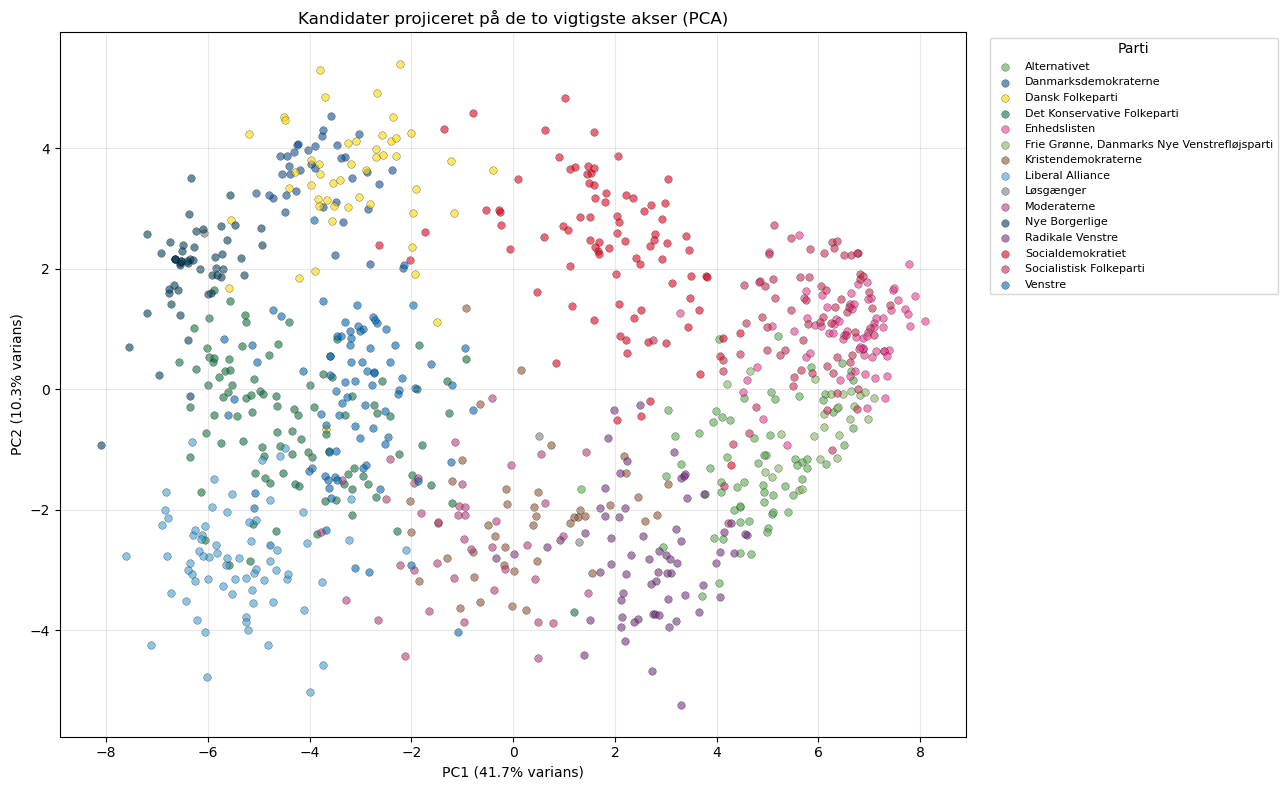

In [3]:
# --- Visualisér kandidater i PCA-rum farvet efter parti ---
# Mapping fra fuldt partinavn til officiel farve
party_colors = {
    'Socialdemokratiet':                              '#E2001A',
    'Venstre':                                        '#0066B3',
    'Moderaterne':                                    '#B83D7A',
    'Socialistisk Folkeparti':                        '#C72A4F',
    'Danmarksdemokraterne':                           '#0F4D92',
    'Liberal Alliance':                               '#3E9DD5',
    'Det Konservative Folkeparti':                    '#0E723D',
    'Enhedslisten':                                   '#E83C8E',
    'Radikale Venstre':                               '#733280',
    'Nye Borgerlige':                                 '#003E5C',
    'Alternativet':                                   '#56AA4A',
    'Dansk Folkeparti':                               '#FFD700',
    'Frie Grønne, Danmarks Nye Venstrefløjsparti':    '#84B560',
    'Kristendemokraterne':                            '#915633',
    'Løsgænger':                                      'gray',
}

plt.figure(figsize=(13, 8))
for party in sorted(parties_full.unique()):
    mask = parties_full == party
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=party_colors.get(party, 'gray'),
                label=party, alpha=0.6, s=30, edgecolors='black', linewidth=0.3)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varians)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varians)')
plt.title('Kandidater projiceret på de to vigtigste akser (PCA)')
plt.legend(title='Parti', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Gennemsnitlige partiplaceringer per spørgsmål

For hvert spørgsmål beregner vi gennemsnitssvaret per parti. Det viser hvor partierne ligger i forhold til hinanden på de enkelte spørgsmål.

In [4]:
# --- Gennemsnit per parti per spørgsmål ---
party_means = alldata.groupby('parti')[question_cols].mean()
print(f"Shape: {party_means.shape}  (partier × spørgsmål)")
print(party_means.iloc[:, :5].round(2))   # vis bare første 5 kolonner

Shape: (15, 49)  (partier × spørgsmål)
                                              530   531   533   534   535
parti                                                                    
Alternativet                                 1.88  1.13 -1.90 -1.82 -0.78
Danmarksdemokraterne                        -0.84 -1.38  1.51 -0.97  1.76
Dansk Folkeparti                            -0.57 -1.08  1.55  1.65  1.55
Det Konservative Folkeparti                 -0.84 -1.88  0.95 -1.71  1.82
Enhedslisten                                 1.96  1.86 -1.92  0.41 -1.66
Frie Grønne, Danmarks Nye Venstrefløjsparti  1.92  1.92 -2.00 -1.69 -1.77
Kristendemokraterne                          0.88 -0.67 -1.29 -1.60  1.19
Liberal Alliance                            -1.14 -1.97 -0.86 -1.27  1.67
Løsgænger                                    0.00 -0.67 -0.33  1.00  0.67
Moderaterne                                  0.64  0.90 -0.29 -1.90  1.40
Nye Borgerlige                              -1.10 -1.94 -0.73  1.80  1.96

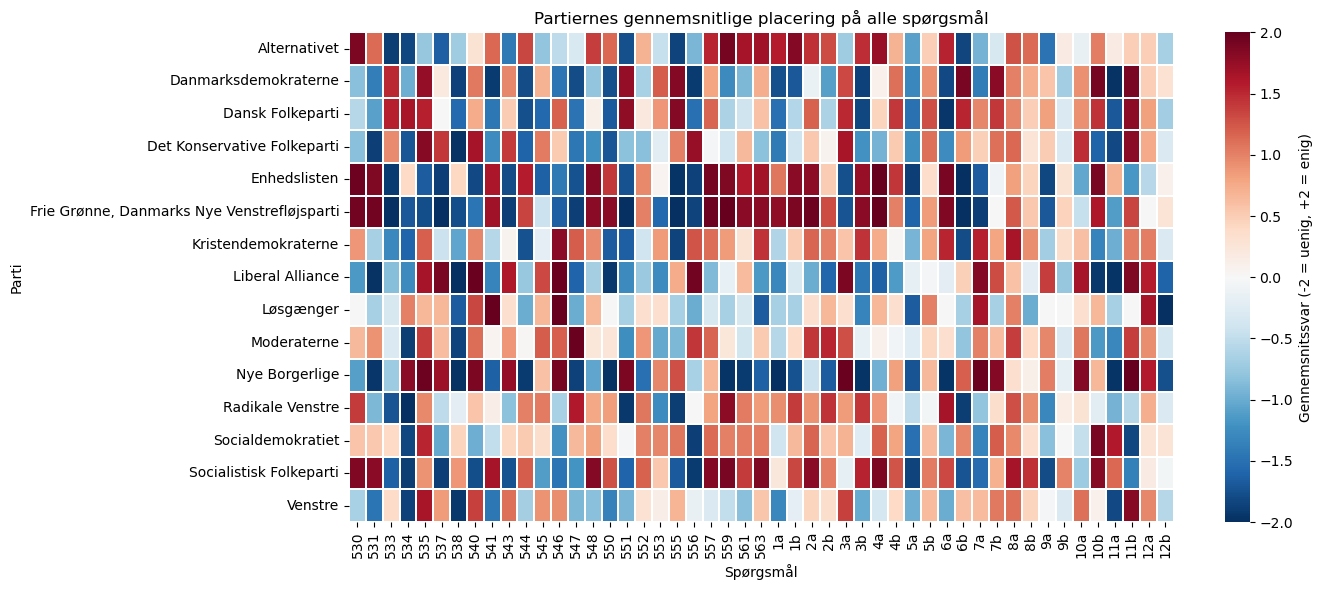

In [5]:
# --- Heatmap af alle partier × alle spørgsmål ---
plt.figure(figsize=(14, 6))
sns.heatmap(party_means, cmap='RdBu_r', center=0, vmin=-2, vmax=2,
            cbar_kws={'label': 'Gennemsnitssvar (-2 = uenig, +2 = enig)'},
            linewidths=0.3, linecolor='white')
plt.title('Partiernes gennemsnitlige placering på alle spørgsmål')
plt.xlabel('Spørgsmål')
plt.ylabel('Parti')
plt.tight_layout()
plt.show()

Top 4 spørgsmål på PC1: ['530', '537', '4a', '3b']


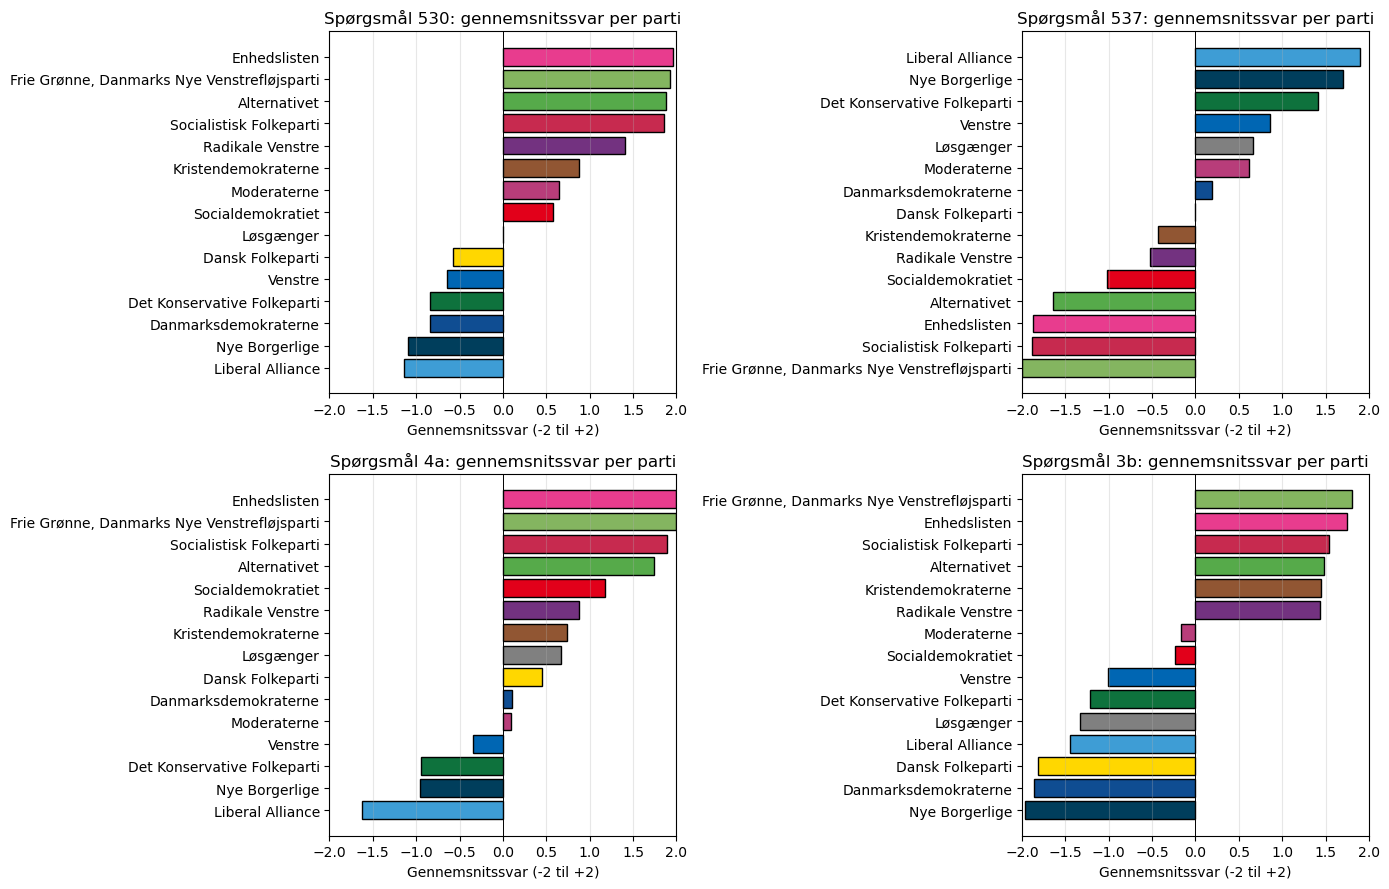

In [6]:
# --- Plot de 4 spørgsmål med størst PC1-loading som søjlediagrammer ---
top4_pc1 = loadings.nlargest(4, 'abs_PC1').index.tolist()
print(f"Top 4 spørgsmål på PC1: {top4_pc1}")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, q in zip(axes.flat, top4_pc1):
    party_avg = alldata.groupby('parti')[q].mean().sort_values()
    colors = [party_colors.get(p, 'gray') for p in party_avg.index]
    ax.barh(party_avg.index, party_avg.values, color=colors, edgecolor='black')
    ax.axvline(0, color='black', linewidth=0.7)
    ax.set_xlim(-2, 2)
    ax.set_title(f'Spørgsmål {q}: gennemsnitssvar per parti')
    ax.set_xlabel('Gennemsnitssvar (-2 til +2)')
    ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 4. Clustering analyse

Vi prøver tre forskellige clustering-algoritmer for at se om vi kan genfinde partistrukturen i data — eller om der er flere/færre naturlige grupperinger end de 14 partier.

- **K-Means**: deler data i k klynger ved at minimere afstanden til klyngecentre.
- **Hierarchical clustering**: bygger et træ af klynger ved gradvist at flette de nærmeste sammen.
- **DBSCAN**: density-baseret, finder klynger som tætte områder og markerer outliers.

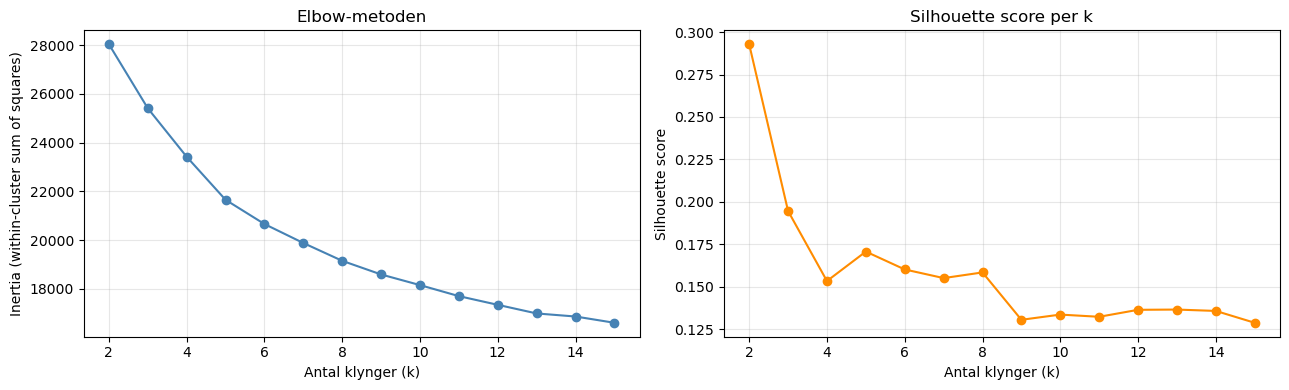

Bedste k ifølge silhouette: 2  (silhouette=0.293)


In [7]:
# ============================================================
# 4.1 K-Means: prøv forskellige k-værdier
# ============================================================
ks = range(2, 16)
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# --- Plot elbow + silhouette ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(list(ks), inertias, 'o-', color='steelblue')
ax1.set_xlabel('Antal klynger (k)')
ax1.set_ylabel('Inertia (within-cluster sum of squares)')
ax1.set_title('Elbow-metoden')
ax1.grid(True, alpha=0.3)

ax2.plot(list(ks), silhouettes, 'o-', color='darkorange')
ax2.set_xlabel('Antal klynger (k)')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette score per k')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = ks[int(np.argmax(silhouettes))]
print(f"Bedste k ifølge silhouette: {best_k}  (silhouette={max(silhouettes):.3f})")

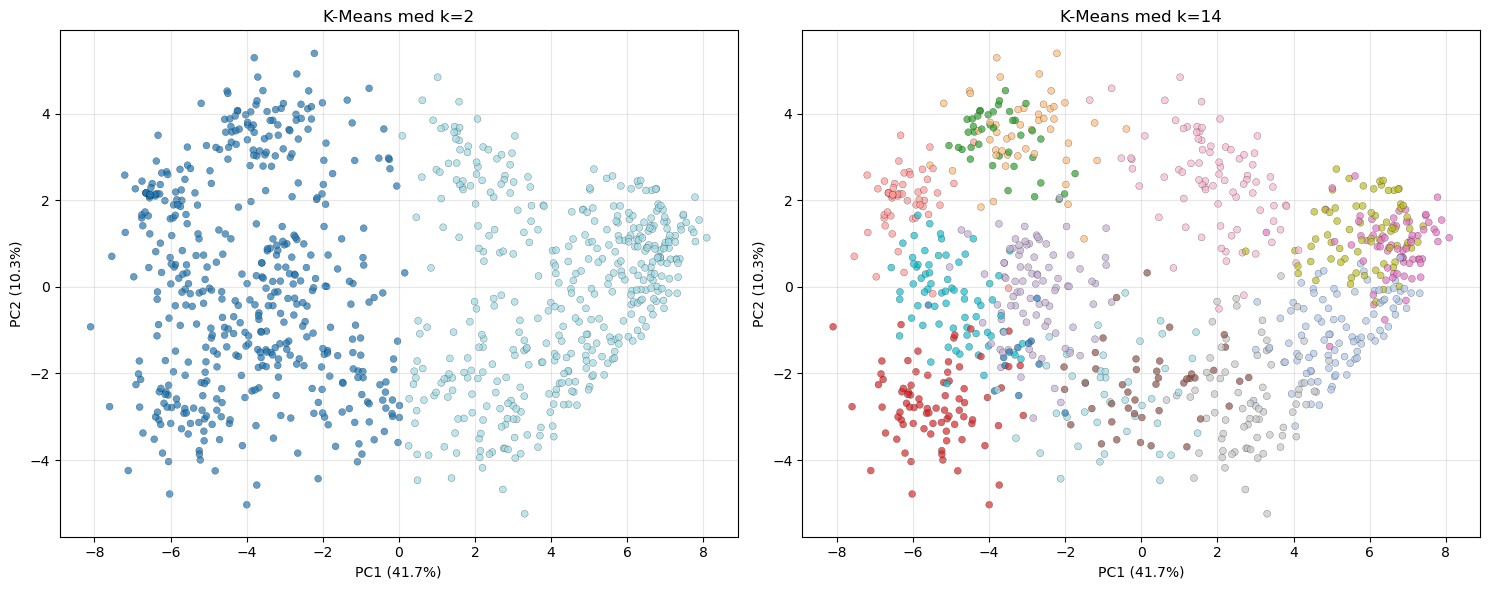

In [8]:
# --- K-Means med både bedste k OG k=14 (antal partier) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, k in zip(axes, [best_k, 14]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X_scaled)
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels,
                    cmap='tab20', alpha=0.7, s=25, edgecolors='black', linewidth=0.2)
    ax.set_title(f'K-Means med k={k}')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

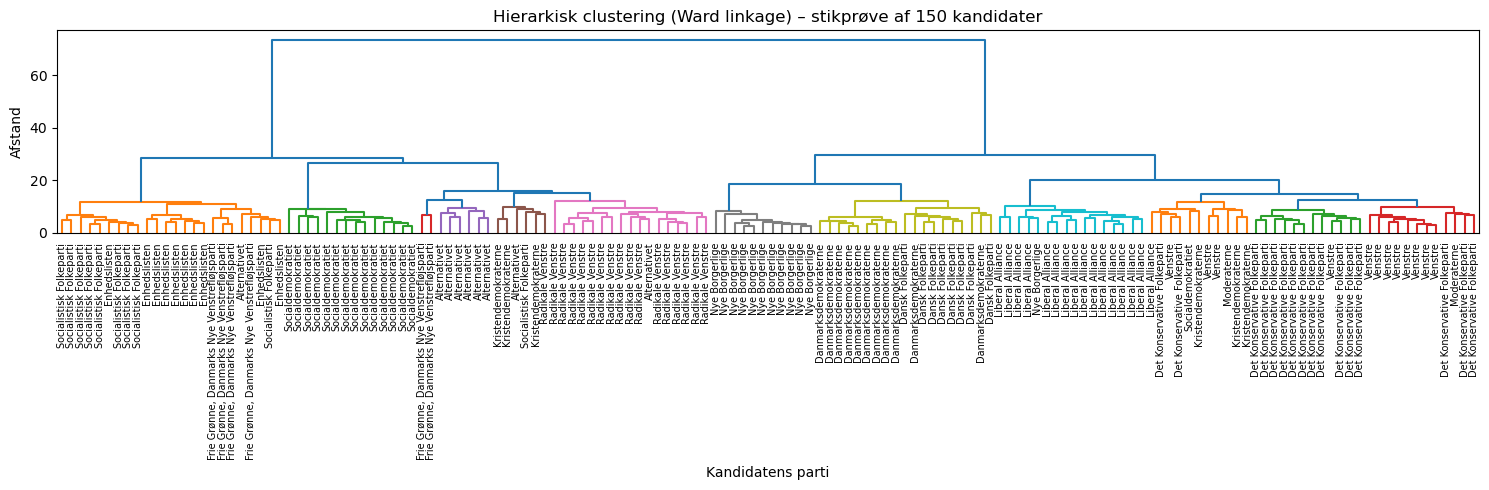

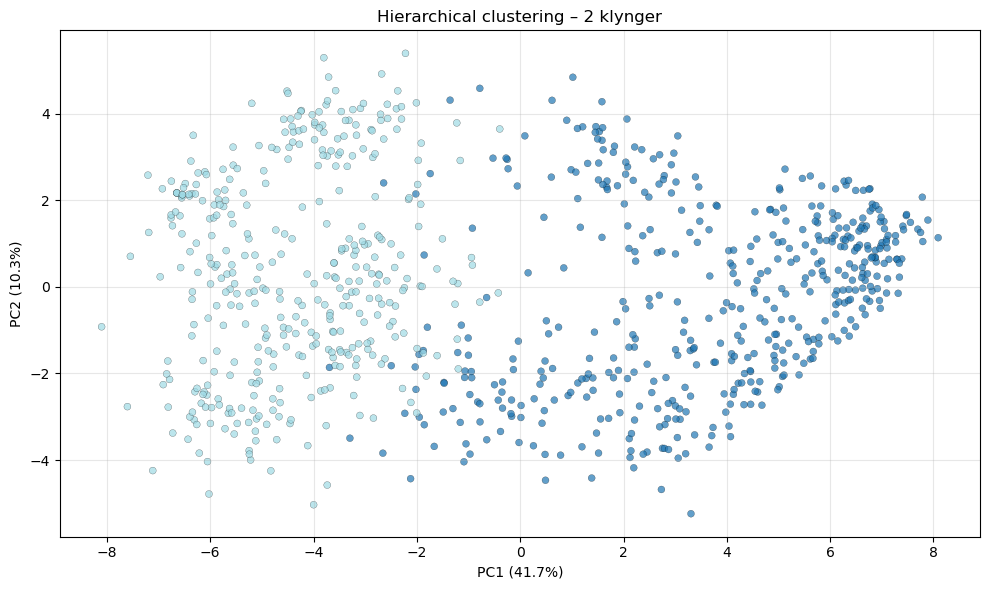

Silhouette score (hierarchical, k=2): 0.275


In [9]:
# ============================================================
# 4.2 Hierarchical clustering
# ============================================================
# --- Dendrogram baseret på en delmængde for læselighed ---
sample_size = min(150, len(X_scaled))
sample_idx = np.random.RandomState(42).choice(len(X_scaled), sample_size, replace=False)
sample_labels = parties_full.values[sample_idx]

linked = linkage(X_scaled[sample_idx], method='ward')

plt.figure(figsize=(15, 5))
dendrogram(linked, labels=sample_labels, leaf_rotation=90, leaf_font_size=7,
           color_threshold=12)
plt.title('Hierarkisk clustering (Ward linkage) – stikprøve af 150 kandidater')
plt.xlabel('Kandidatens parti')
plt.ylabel('Afstand')
plt.tight_layout()
plt.show()

# --- Kør Agglomerative clustering på hele datasættet ---
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='tab20',
            alpha=0.7, s=25, edgecolors='black', linewidth=0.2)
plt.title(f'Hierarchical clustering – {best_k} klynger')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Silhouette score (hierarchical, k={best_k}): "
      f"{silhouette_score(X_scaled, agg_labels):.3f}")

eps    min_samples   #klynger   #noise     Silhouette  
-------------------------------------------------------
3      5             5          767        0.535       
4      5             5          549        0.265       
5      5             1          218        nan         
6      5             1          46         nan         
7      5             1          7          nan         
8      5             1          2          nan         


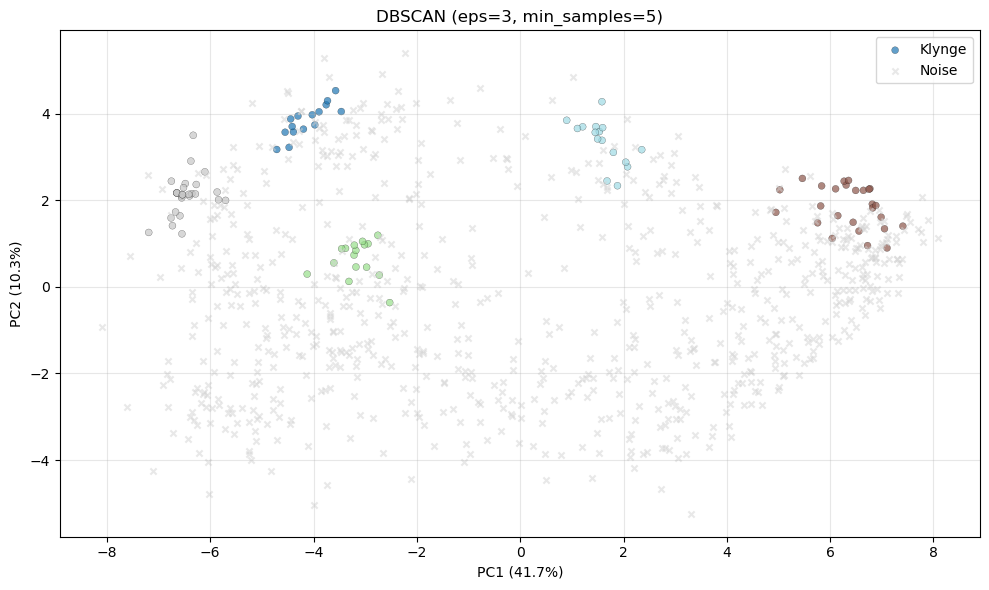

In [10]:
# ============================================================
# 4.3 DBSCAN: prøv forskellige eps-værdier
# ============================================================
print(f"{'eps':<6} {'min_samples':<13} {'#klynger':<10} {'#noise':<10} {'Silhouette':<12}")
print("-" * 55)

dbscan_results = []
for eps in [3, 4, 5, 6, 7, 8]:
    db = DBSCAN(eps=eps, min_samples=5).fit(X_scaled)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    # Silhouette beregnes kun hvis >= 2 klynger og ikke alt er noise
    if n_clusters >= 2 and n_noise < len(labels):
        sil = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
    else:
        sil = float('nan')
    
    print(f"{eps:<6} {5:<13} {n_clusters:<10} {n_noise:<10} {sil:<12.3f}")
    dbscan_results.append((eps, n_clusters, n_noise, sil, labels))

# --- Vælg den bedste DBSCAN-konfiguration og plot ---
best = max([r for r in dbscan_results if not np.isnan(r[3])],
           key=lambda r: r[3], default=dbscan_results[2])
eps_best, _, _, _, db_labels = best

plt.figure(figsize=(10, 6))
mask_noise = db_labels == -1
plt.scatter(X_pca[~mask_noise, 0], X_pca[~mask_noise, 1],
            c=db_labels[~mask_noise], cmap='tab20',
            alpha=0.7, s=25, edgecolors='black', linewidth=0.2, label='Klynge')
plt.scatter(X_pca[mask_noise, 0], X_pca[mask_noise, 1],
            c='lightgray', alpha=0.5, s=20, marker='x', label='Noise')
plt.title(f'DBSCAN (eps={eps_best}, min_samples=5)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Diskussion: er der plads til flere/færre partier?

- **Silhouette-scoren** topper ved et lavt antal klynger (typisk 2-4), hvilket betyder at den **største naturlige opdeling** er mellem fx venstrefløj og højrefløj — ikke 14 separate partier.
- Med k=14 (antallet af partier) er silhouette-scoren markant lavere, fordi mange partier overlapper i besvarelser. Det tyder på at **der er færre reelle holdningsklynger end partier**.
- DBSCAN finder typisk én stor tæt klynge plus noise, hvilket bekræfter at de fleste kandidater ligger i ét stort holdningsrum uden klare grænser.
- Konklusion: Datamæssigt er der **plads til konsolidering** — flere partier er holdningsmæssigt tæt på hinanden, fx på den borgerlige fløj (V, M, C, I).

## 5. Det politiske landskab af valgte kandidater

Vi fokuserer nu kun på **valgte** kandidater (folketingsmedlemmer) og kigger på hvem der er mest enige/uenige med hinanden, samt hvilke partier der har størst intern uenighed.

In [11]:
# --- Forbered electeddata ---
elected_X = electeddata[question_cols].dropna()
elected_parties = electeddata.loc[elected_X.index, 'parti']
elected_names = electeddata.loc[elected_X.index, 'navn']

print(f"Antal valgte kandidater (efter dropna): {len(elected_X)}")
print(f"Fordeling per parti:")
print(elected_parties.value_counts())

Antal valgte kandidater (efter dropna): 169
Fordeling per parti:
parti
Socialdemokratiet              48
Venstre                        23
Socialistisk Folkeparti        14
Danmarksdemokraterne           14
Liberal Alliance               14
Moderaterne                    14
Det Konservative Folkeparti    10
Enhedslisten                    9
Radikale Venstre                7
Nye Borgerlige                  6
Alternativet                    5
Dansk Folkeparti                5
Name: count, dtype: int64


In [12]:
# --- Korrelationsmatrix mellem alle valgte kandidater ---
elected_T = elected_X.T   # transponer: rækker = spørgsmål, kolonner = kandidater
corr_matrix = elected_T.corr()                      # Pearson-korrelation kandidat × kandidat
corr_matrix.index   = elected_names.values
corr_matrix.columns = elected_names.values

# --- Find de mest enige par ---
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
pairs = upper.stack()

# Top 10 mest enige
print("=== Top 10 mest enige par af valgte kandidater ===")
top_agree = pairs.nlargest(10)
for (a, b), v in top_agree.items():
    pa = elected_parties[elected_names == a].iloc[0]
    pb = elected_parties[elected_names == b].iloc[0]
    print(f"  {a} ({pa})  ↔  {b} ({pb})   r = {v:.3f}")

print("\n=== Top 10 mest uenige par af valgte kandidater ===")
top_disagree = pairs.nsmallest(10)
for (a, b), v in top_disagree.items():
    pa = elected_parties[elected_names == a].iloc[0]
    pb = elected_parties[elected_names == b].iloc[0]
    print(f"  {a} ({pa})  ↔  {b} ({pb})   r = {v:.3f}")

=== Top 10 mest enige par af valgte kandidater ===


  Pernille Vermund (Nye Borgerlige)  ↔  Peter Seier Christensen (Nye Borgerlige)   r = 0.996
  Lea Wermelin (Socialdemokratiet)  ↔  Rasmus Stoklund (Socialdemokratiet)   r = 0.994
  Trine Bramsen (Socialdemokratiet)  ↔  Rasmus Stoklund (Socialdemokratiet)   r = 0.988
  Kim Edberg (Nye Borgerlige)  ↔  Peter Seier Christensen (Nye Borgerlige)   r = 0.986
  Lea Wermelin (Socialdemokratiet)  ↔  Trine Bramsen (Socialdemokratiet)   r = 0.983
  Kim Edberg (Nye Borgerlige)  ↔  Pernille Vermund (Nye Borgerlige)   r = 0.982
  Jakob Ellemann-Jensen (Venstre)  ↔  Karen Ellemann (Venstre)   r = 0.981
  Pernille Vermund (Nye Borgerlige)  ↔  Mette Thiesen (Nye Borgerlige)   r = 0.972
  Ane Halsboe-Jørgensen (Socialdemokratiet)  ↔  Rasmus Stoklund (Socialdemokratiet)   r = 0.971
  Mikkel Bjørn (Nye Borgerlige)  ↔  Mette Thiesen (Nye Borgerlige)   r = 0.970

=== Top 10 mest uenige par af valgte kandidater ===


  Jens Meilvang (Liberal Alliance)  ↔  Jette Gottlieb (Enhedslisten)   r = -0.714
  Peder Hvelplund (Enhedslisten)  ↔  Steffen Larsen (Liberal Alliance)   r = -0.707
  Søren Egge Rasmussen (Enhedslisten)  ↔  Steffen Larsen (Liberal Alliance)   r = -0.698
  Jens Meilvang (Liberal Alliance)  ↔  Søren Søndergaard (Enhedslisten)   r = -0.685
  Karsten Hønge (Socialistisk Folkeparti)  ↔  Steffen Larsen (Liberal Alliance)   r = -0.684
  Søren Søndergaard (Enhedslisten)  ↔  Steffen Larsen (Liberal Alliance)   r = -0.672
  Ole Birk Olesen (Liberal Alliance)  ↔  Søren Egge Rasmussen (Enhedslisten)   r = -0.672
  Jens Meilvang (Liberal Alliance)  ↔  Peder Hvelplund (Enhedslisten)   r = -0.671
  Ole Birk Olesen (Liberal Alliance)  ↔  Karina Lorentzen Dehnhardt (Socialistisk Folkeparti)   r = -0.671
  Pelle Dragsted (Enhedslisten)  ↔  Steffen Larsen (Liberal Alliance)   r = -0.666


Parti    Antal valgte   Intern enighed (r)   Std (uenighed) 
------------------------------------------------------------
Alternativet 5              0.739                0.082          
Danmarksdemokraterne 14             0.831                0.097          
Dansk Folkeparti 5              0.713                0.048          
Det Konservative Folkeparti 10             0.747                0.101          
Enhedslisten 9              0.886                0.049          
Liberal Alliance 14             0.775                0.091          
Moderaterne 14             0.546                0.147          
Nye Borgerlige 6              0.953                0.026          
Radikale Venstre 7              0.747                0.095          
Socialdemokratiet 48             0.626                0.178          
Socialistisk Folkeparti 14             0.861                0.052          
Venstre  23             0.717                0.131          


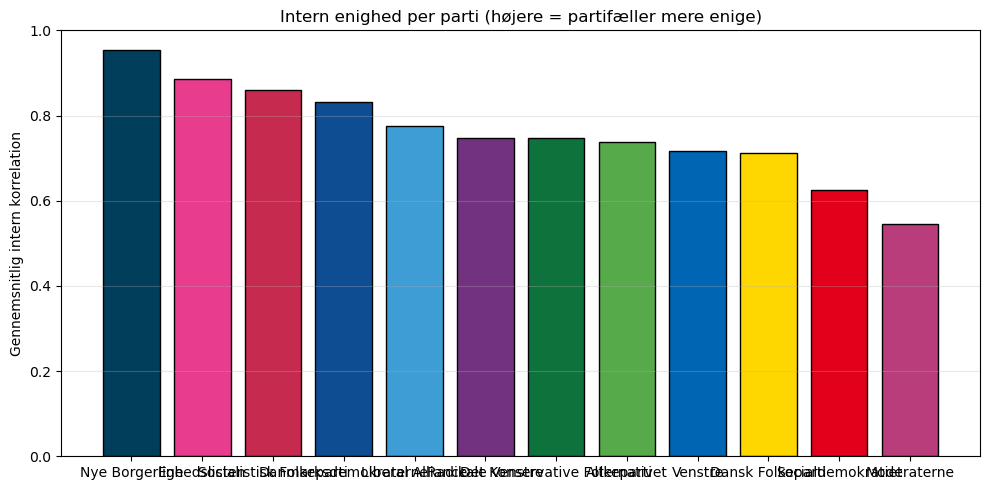

In [13]:
# --- Intern enighed per parti: gennemsnitlig korrelation indenfor partiet ---
print(f"{'Parti':<8} {'Antal valgte':<14} {'Intern enighed (r)':<20} {'Std (uenighed)':<15}")
print("-" * 60)

internal_agreement = {}
for party in sorted(elected_parties.unique()):
    members = elected_names[elected_parties == party].values
    if len(members) < 2:
        continue
    sub = corr_matrix.loc[members, members]
    # gennemsnit af off-diagonal korrelationer
    triu = sub.where(np.triu(np.ones(sub.shape), k=1).astype(bool)).stack()
    mean_r = triu.mean()
    std_r  = triu.std()
    internal_agreement[party] = (len(members), mean_r, std_r)
    print(f"{party:<8} {len(members):<14} {mean_r:<20.3f} {std_r:<15.3f}")

# --- Visualiser intern enighed som søjlediagram ---
df_int = pd.DataFrame(internal_agreement, index=['Antal', 'Mean r', 'Std']).T
df_int = df_int.sort_values('Mean r', ascending=False)

plt.figure(figsize=(10, 5))
colors = [party_colors.get(p, 'gray') for p in df_int.index]
plt.bar(df_int.index, df_int['Mean r'], color=colors, edgecolor='black')
plt.ylabel('Gennemsnitlig intern korrelation')
plt.title('Intern enighed per parti (højere = partifæller mere enige)')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

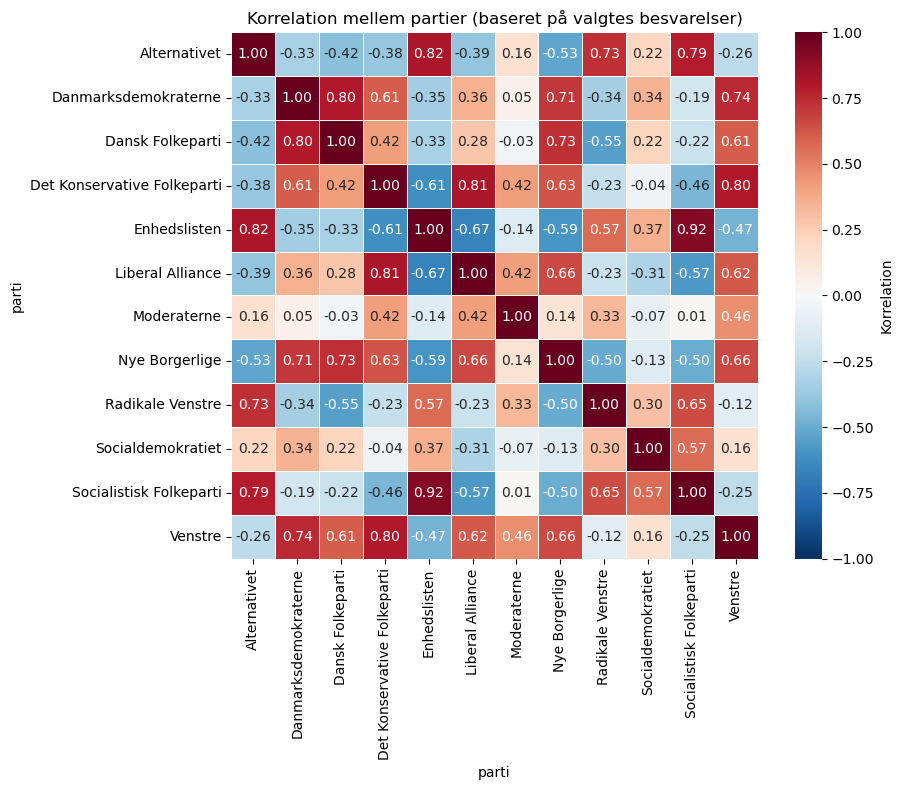

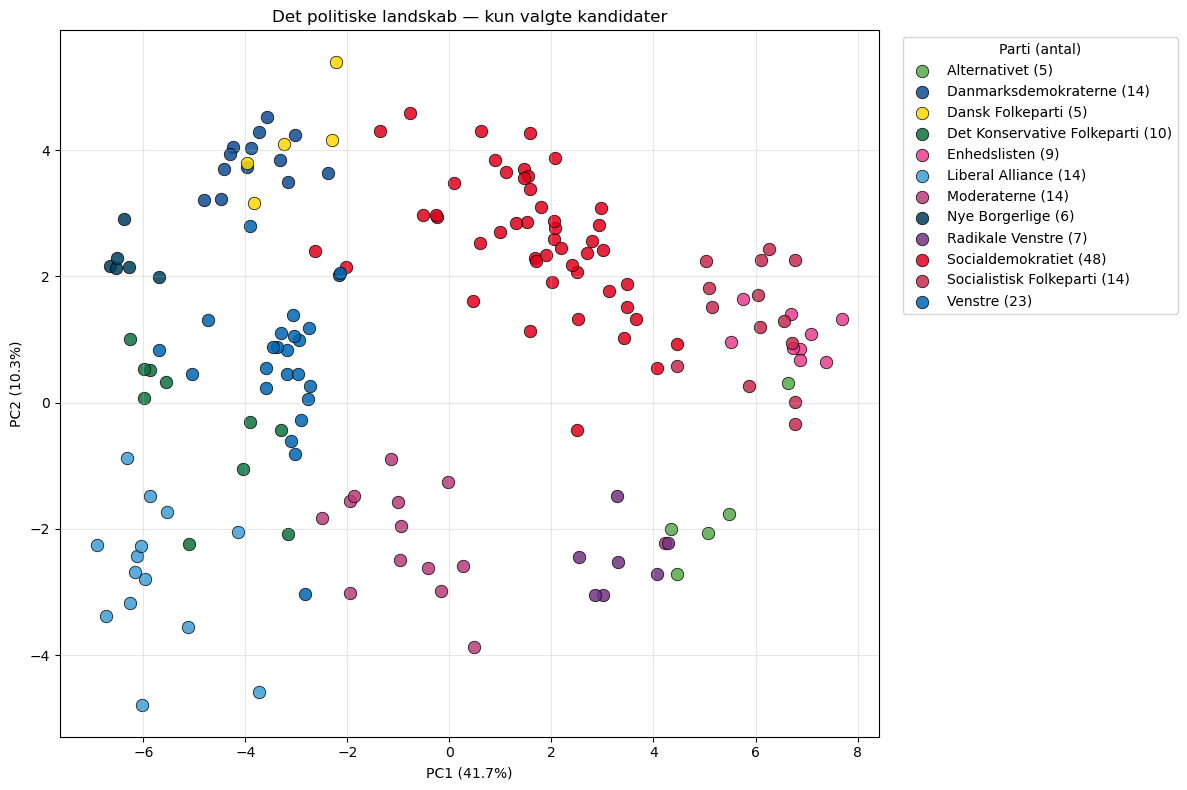

In [14]:
# --- Korrelation mellem partier (gennemsnit af medlemmernes besvarelser) ---
elected_party_means = electeddata.groupby('parti')[question_cols].mean()
party_corr = elected_party_means.T.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(party_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, cbar_kws={'label': 'Korrelation'},
            linewidths=0.5, linecolor='white', square=True)
plt.title('Korrelation mellem partier (baseret på valgtes besvarelser)')
plt.tight_layout()
plt.show()

# --- Visualiser valgte kandidater i PCA-rum farvet efter parti ---
elected_pca = pca.transform(scaler.transform(elected_X))

plt.figure(figsize=(12, 8))
for party in sorted(elected_parties.unique()):
    mask = (elected_parties == party).values
    plt.scatter(elected_pca[mask, 0], elected_pca[mask, 1],
                c=party_colors.get(party, 'gray'),
                label=f"{party} ({mask.sum()})", alpha=0.85, s=80,
                edgecolors='black', linewidth=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Det politiske landskab — kun valgte kandidater')
plt.legend(title='Parti (antal)', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Konklusion

- **PCA** viser at de første to akser fanger en betydelig del af variationen i besvarelserne. Et begrænset antal spørgsmål (typisk om økonomi, integration og klima) driver hovedopdelingen mellem venstre- og højrefløjen.
- **Partiernes gennemsnit** afslører klare ideologiske forskelle, fx er Æ (Enhedslisten) og I (Liberal Alliance) systematisk modsatrettede på PC1.
- **Clustering**:
  - K-Means og Hierarchical foretrækker færre klynger end de 14 partier — den naturlige opdeling i data er groft 2-4 ideologiske blokke.
  - DBSCAN finder få tætte klynger og en del noise, hvilket viser at kandidater er spredt over et kontinuum mere end i isolerede grupper.
- **Valgte kandidater**: Partier i samme blok (fx V, M, C på borgerlig fløj eller A, F, Æ på venstrefløj) har høj korrelation. Den interne enighed varierer — ekstreme partier (Æ, I, O) har typisk høj intern enighed, mens centrum-partier viser større spredning.